In [2]:
import sys
import os

# !pip install pandas
# !pip install seaborn
# !pip install qiskit-aer
import pandas as pd
import numpy as np

import random
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, skewnorm, t, chi2, gamma
from scipy.stats import kstest
import json
import math

from qiskit.synthesis import LieTrotter
from qiskit.transpiler import CouplingMap
from qiskit_addon_utils.problem_generators import generate_xyz_hamiltonian
from qiskit_addon_utils.problem_generators import generate_time_evolution_circuit
from qiskit.quantum_info import SparsePauliOp

src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'utils'))
if src_path not in sys.path:
    sys.path.append(src_path)

# from qiskit_addon_obp.classical_shadows import run_shadow, calculate_shadow_sample_complexity
# from qiskit_addon_obp.run import run_many, obp_protocol
# from qiskit_addon_obp.obp import run_backpropagation

In [3]:
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
import rustworkx as rx
from qiskit.compiler import transpile

10.7


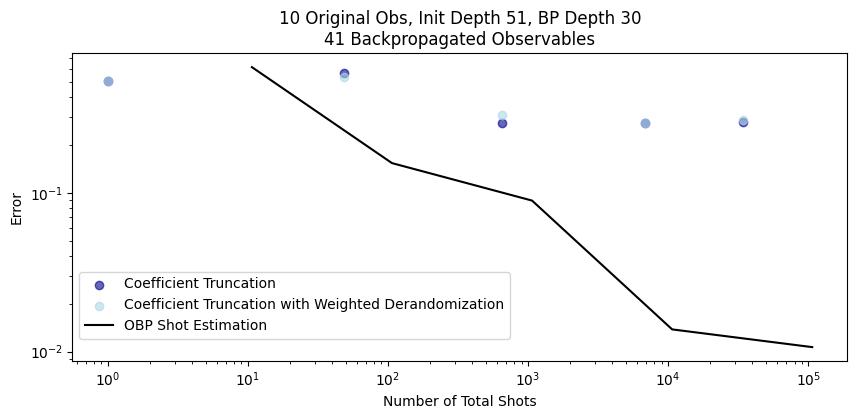

In [28]:
data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_QAOA'))
# noisy_data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_noisy'))

bp_depth_30 = pd.read_pickle(f'{data_path}/coef-trunc_reps2_n5_k3_g073_b042_depth30.pkl')
bp_depth_30_weighted = pd.read_pickle(f'{data_path}/coef-trunc_reps2_n5_k3_g073_b042_depth30_weighted.pkl')

# bp_depth_80 = pd.read_pickle(f'{data_path}/bp_depth_80.pkl')

obp_df = pd.read_pickle(f'{data_path}/obp-reps2_n5_k3_g073_b042_depth30.pkl')

# noisy_coef_df = pd.read_pickle(f'{noisy_data_path}/coef-trunc_init90_bp10_obs3.pkl')

# pauli_df = pd.read_pickle(f'{data_path}/pauli-trunc7_init90_bp5_obs9.pkl')
# obp_df = pd.read_pickle(f'{data_path}/obp_bp10_obs3.pkl')
# shad_df = pd.read_pickle(f'{data_path}/shad_res_3.pkl')

obp_df['num_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.paulis))
obp_df['num_qwc_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.group_commuting(qubit_wise=True)))
obp_df['num_total_shots'] = obp_df['num_qwc_bp_obs'] * obp_df['obp_shots']

obs_num = 10
bp_depth_30['obs_group'] = bp_depth_30.index // obs_num
bp_depth_30_weighted['obs_group'] = bp_depth_30_weighted.index // obs_num

obp_df['obs_group'] = obp_df.index // obs_num
# shad_df['obs_group'] = shad_df.index // obs_num
# pauli_df['obs_group'] = pauli_df.index // obs_num

gb30 = bp_depth_30.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
gb30_weighted = bp_depth_30_weighted.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
# gb_noisy = noisy_coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

# gb2 = pauli_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

gb_obp = obp_df.groupby('obs_group').agg({'num_total_shots': 'mean', 'abs_bp_error_shots': 'mean'}).reset_index()

# gb_shad = shad_df.groupby('num_meas').agg({'abs_shad_error': 'mean'}).reset_index()

plt.figure(figsize=(10, 4))

plt.scatter(x=gb30['num_meas'], y=gb30['abs_total_error'], label='Coefficient Truncation', alpha=0.6, color='darkblue')
plt.scatter(x=gb30_weighted['num_meas'], y=gb30_weighted['abs_total_error'], label='Coefficient Truncation with Weighted Derandomization', alpha=0.6, color='lightblue')

# plt.scatter(x=gb_noisy['num_meas'], y=gb_noisy['abs_total_error'], label='Noisy Coefficient Truncation', alpha=0.6, color='lightblue')

# plt.scatter(x=gb2['num_meas'], y=gb2['abs_total_error'], label='Pauli Weight Truncation (7)', alpha=0.6, color='lightblue')

sns.lineplot(data=gb_obp, x='num_total_shots', y='abs_bp_error_shots', label='OBP Shot Estimation', color='black')
# plt.axhline(y=obp_df['abs_bp_error_state'].mean(), color='black', linestyle='--', label='OBP Statevector')
# sns.lineplot(data=gb_shad, x='num_meas', y='abs_shad_error', label='Shadow on Initial', color='gray')

plt.xscale('log')
plt.yscale('log')
plt.title(f'{obs_num} Original Obs, Init Depth 51, BP Depth 30\n{int(math.ceil(obp_df["num_bp_obs"].mean()))} Backpropagated Observables')
plt.xlabel('Number of Total Shots')
plt.ylabel('Error')

plt.legend(loc='lower left', bbox_to_anchor=(0, 0.05))

print(obp_df['num_qwc_bp_obs'].mean())

# y_hline = gb1['abs_total_error'].min()
# y_hline = sorted(gb_noisy['abs_total_error'])[1]
# print(gb1[gb1['abs_total_error'] == y_hline])
# y_min = gb_noisy[gb_noisy['abs_total_error'] == y_hline]['num_meas'].values[0]
# diff = gb_obp['abs_bp_error_shots'] - y_hline
# crossings = diff.shift(-1) * diff < 0
# for idx in gb_obp.index[crossings]:
#     x0 = gb_obp.loc[idx, 'num_total_shots']
#     y0 = gb_obp.loc[idx, 'abs_bp_error_shots']
#     x1 = gb_obp.loc[idx + 1, 'num_total_shots']
#     y1 = gb_obp.loc[idx + 1, 'abs_bp_error_shots']
#     # Linear interpolation
#     if y1 != y0:
#         x_intersect = x0 + (y_hline - y0) * (x1 - x0) / (y1 - y0)
#         print(f"Intersection at num_total_shots ≈ {x_intersect:.2f}")
#         print(f"OBP-Shadow improvement is {x_intersect / y_min:.2f} times the minimum number of measurements for the coefficient truncation method.")

100.0


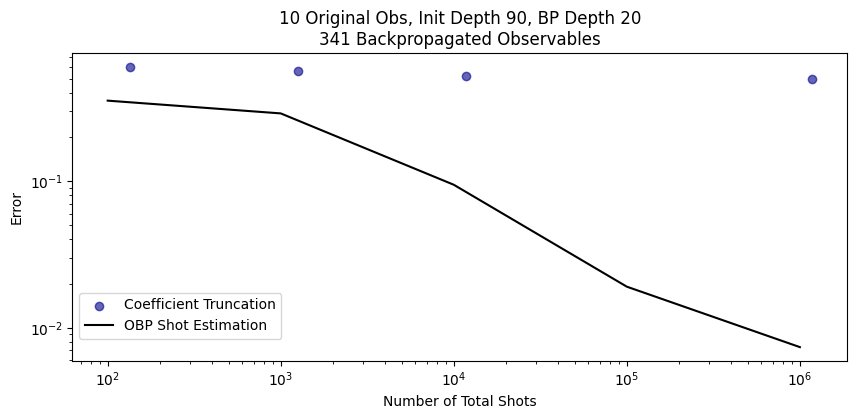

In [35]:
data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_QAOA'))
# noisy_data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_noisy'))

bp_depth_20 = pd.read_pickle(f'{data_path}/coef-trunc_reps2_n5_k3_g073_b042_depth20.pkl')
# bp_depth_30_weighted = pd.read_pickle(f'{data_path}/coef-trunc_reps2_n5_k3_g073_b042_depth30_weighted.pkl')

# bp_depth_80 = pd.read_pickle(f'{data_path}/bp_depth_80.pkl')

obp_df = pd.read_pickle(f'{data_path}/obp-reps2_n5_k3_g073_b042_depth20.pkl')

# noisy_coef_df = pd.read_pickle(f'{noisy_data_path}/coef-trunc_init90_bp10_obs3.pkl')

# pauli_df = pd.read_pickle(f'{data_path}/pauli-trunc7_init90_bp5_obs9.pkl')
# obp_df = pd.read_pickle(f'{data_path}/obp_bp10_obs3.pkl')
# shad_df = pd.read_pickle(f'{data_path}/shad_res_3.pkl')

obp_df['num_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.paulis))
obp_df['num_qwc_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.group_commuting(qubit_wise=True)))
obp_df['num_total_shots'] = obp_df['num_qwc_bp_obs'] * obp_df['obp_shots']

obs_num = 10
bp_depth_20['obs_group'] = bp_depth_20.index // obs_num

obp_df['obs_group'] = obp_df.index // obs_num

gb20 = bp_depth_20.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

gb_obp = obp_df.groupby('obs_group').agg({'num_total_shots': 'mean', 'abs_bp_error_shots': 'mean'}).reset_index()

plt.figure(figsize=(10, 4))

plt.scatter(x=gb20['num_meas'], y=gb20['abs_total_error'], label='Coefficient Truncation', alpha=0.6, color='darkblue')

sns.lineplot(data=gb_obp, x='num_total_shots', y='abs_bp_error_shots', label='OBP Shot Estimation', color='black')
# plt.axhline(y=obp_df['abs_bp_error_state'].mean(), color='black', linestyle='--', label='OBP Statevector')
# sns.lineplot(data=gb_shad, x='num_meas', y='abs_shad_error', label='Shadow on Initial', color='gray')

plt.xscale('log')
plt.yscale('log')
plt.title(f'{obs_num} Original Obs, Init Depth 90, BP Depth 20\n{int(math.ceil(obp_df["num_bp_obs"].mean()))} Backpropagated Observables')
plt.xlabel('Number of Total Shots')
plt.ylabel('Error')

plt.legend(loc='lower left', bbox_to_anchor=(0, 0.05))

print(obp_df['num_qwc_bp_obs'].mean())

# y_hline = gb1['abs_total_error'].min()
# y_hline = sorted(gb_noisy['abs_total_error'])[1]
# print(gb1[gb1['abs_total_error'] == y_hline])
# y_min = gb_noisy[gb_noisy['abs_total_error'] == y_hline]['num_meas'].values[0]
# diff = gb_obp['abs_bp_error_shots'] - y_hline
# crossings = diff.shift(-1) * diff < 0
# for idx in gb_obp.index[crossings]:
#     x0 = gb_obp.loc[idx, 'num_total_shots']
#     y0 = gb_obp.loc[idx, 'abs_bp_error_shots']
#     x1 = gb_obp.loc[idx + 1, 'num_total_shots']
#     y1 = gb_obp.loc[idx + 1, 'abs_bp_error_shots']
#     # Linear interpolation
#     if y1 != y0:
#         x_intersect = x0 + (y_hline - y0) * (x1 - x0) / (y1 - y0)
#         print(f"Intersection at num_total_shots ≈ {x_intersect:.2f}")
#         print(f"OBP-Shadow improvement is {x_intersect / y_min:.2f} times the minimum number of measurements for the coefficient truncation method.")

In [34]:
pd.DataFrame(bp_depth_20['obs_shad_dict'][0])

,obs,estimate,exact,error,var
0,IIIZZ,0.000000,5.038737e-01,0.503874,1.076923
1,IZIZZ,-0.500000,0.000000e+00,0.500000,1.000000
2,ZIIZZ,0.200000,0.000000e+00,-0.200000,1.200000
3,ZZIZZ,0.200000,4.828360e-01,0.282836,1.200000
4,XIIZZ,0.200000,-9.198635e-02,-0.291986,1.200000
...,...,...,...,...,...
484,IZYXZ,-0.333333,5.551115e-17,0.333333,1.333333
485,IXYXY,0.333333,9.198635e-02,-0.241347,1.333333
486,IYYXY,-0.333333,5.204170e-17,0.333333,1.333333
487,IYYXZ,-0.333333,1.387779e-17,0.333333,1.333333


7.766666666666667
Intersection at num_total_shots ≈ 6112.49
OBP-Shadow improvement is 0.01 times the minimum number of measurements for the coefficient truncation method.


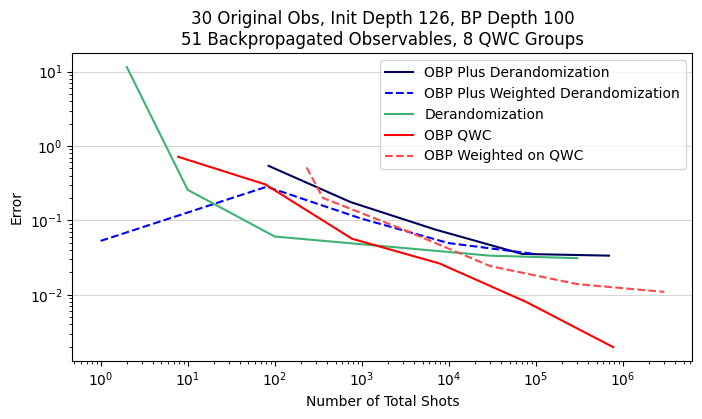

In [13]:
data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_QAOA'))

test = pd.read_pickle(f'{data_path}/coef-trunc_reps2_n10_k6_g073_b042_depth100.pkl')
obp_df = pd.read_pickle(f'{data_path}/obp-reps2_n10_k6_g073_b042_depth100.pkl')
shad_df = pd.read_pickle(f'{data_path}/shad_reps2_n10_k6_g073_b042.pkl')
optimal_shot_df = pd.read_pickle(f'{data_path}/optimal_obp-reps2_n10_k6_g073_b042.pkl')
coef_weight_df = pd.read_pickle(f'{data_path}/weighted_coef-trunc_reps2_n10_k6_g073_b042_depth100.pkl')

obp_df['num_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.paulis))
obp_df['num_qwc_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.group_commuting(qubit_wise=True)))
obp_df['num_total_shots'] = obp_df['num_qwc_bp_obs'] * obp_df['obp_shots']

obs_num = obp_df['obs'].nunique()
test['obs_group'] = test.index // obs_num
# noisy_coef_df['obs_group'] = noisy_coef_df.index // obs_num

obp_df['obs_group'] = obp_df.index // obs_num
shad_df['obs_group'] = shad_df.index // obs_num
optimal_shot_df['obs_group'] = optimal_shot_df.index // obs_num
coef_weight_df['obs_group'] = coef_weight_df.index // obs_num

gb100 = test.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
gb100_weight = coef_weight_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

gb_optimal = optimal_shot_df.groupby('obs_group').agg({'obp_shots': 'sum', 'abs_bp_error_shots': 'mean'}).reset_index()
gb_obp = obp_df.groupby('obs_group').agg({'num_total_shots': 'mean', 'abs_bp_error_shots': 'mean'}).reset_index()
gb_shad = shad_df.groupby('num_meas').agg({'abs_shad_error': 'mean'}).reset_index()

plt.figure(figsize=(8, 4))

sns.lineplot(x=gb100['num_meas'], y=gb100['abs_total_error'], label='OBP Plus Derandomization', color='xkcd:dark blue')
sns.lineplot(x=gb100_weight['num_meas'], y=gb100_weight['abs_total_error'], label='OBP Plus Weighted Derandomization', color='blue', linestyle='--')

# sns.lineplot(data=gb_shad, x='num_meas', y='abs_shad_error', label='OBP Plus Derandomization', color='purple')

# plt.scatter(x=gb_noisy['num_meas'], y=gb_noisy['abs_total_error'], label='Noisy Coefficient Truncation', alpha=0.6, color='lightblue')
# plt.scatter(x=gb2['num_meas'], y=gb2['abs_total_error'], label='Pauli Weight Truncation (7)', alpha=0.6, color='lightblue')

sns.lineplot(data=gb_shad, x='num_meas', y='abs_shad_error', label='Derandomization', color='mediumseagreen')

sns.lineplot(data=gb_obp, x='num_total_shots', y='abs_bp_error_shots', label='OBP QWC', color='red')
sns.lineplot(data=gb_optimal, x='obp_shots', y='abs_bp_error_shots', label='OBP Weighted on QWC', color='xkcd:light red', linestyle='--')

# plt.axhline(y=obp_df['abs_bp_error_state'].mean(), color='black', linestyle='--', label='OBP Statevector')

print(obp_df['num_qwc_bp_obs'].mean())

plt.xscale('log')
plt.yscale('log')
plt.title(f'{obs_num} Original Obs, Init Depth 126, BP Depth 100\n{int(math.ceil(obp_df["num_bp_obs"].mean()))} Backpropagated Observables, {int(math.ceil(obp_df["num_qwc_bp_obs"].mean()))} QWC Groups')
plt.xlabel('Number of Total Shots')
plt.ylabel('Error')

plt.legend(loc='upper right', bbox_to_anchor=(1, 1))

plt.grid(which='major', alpha=0.5)
plt.grid(axis='x')

y_hline = gb100['abs_total_error'].min()
y_min = gb100[gb100['abs_total_error'] == y_hline]['num_meas'].values[0]
diff = gb_obp['abs_bp_error_shots'] - y_hline
crossings = diff.shift(-1) * diff < 0
for idx in gb_obp.index[crossings]:
    x0 = gb_obp.loc[idx, 'num_total_shots']
    y0 = gb_obp.loc[idx, 'abs_bp_error_shots']
    x1 = gb_obp.loc[idx + 1, 'num_total_shots']
    y1 = gb_obp.loc[idx + 1, 'abs_bp_error_shots']
    # Linear interpolation
    if y1 != y0:
        x_intersect = x0 + (y_hline - y0) * (x1 - x0) / (y1 - y0)
        print(f"Intersection at num_total_shots ≈ {x_intersect:.2f}")
        print(f"OBP-Shadow improvement is {x_intersect / y_min:.2f} times the minimum number of measurements for the coefficient truncation method.")

In [53]:
for group in obp_df["bp_obs"][0].group_commuting(qubit_wise=True):
    print(max(group.coeffs))

(0.44550662388006446+0j)
(0.006076425164143563-2.7755575615628914e-17j)
(0.05461860142172886-3.469446951953614e-18j)
(-0.05428370000684661+6.938893903907228e-18j)
(0.006039166733280706+0j)
(-0.0065727490293172285+0j)
(0.0014807898381022618-3.469446951953614e-18j)
(0.5377008150832525+0j)
(0.05982025680819713-1.0842021724855044e-19j)


10.55


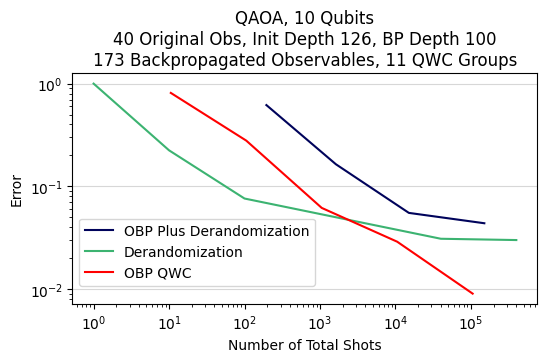

In [8]:
data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_QAOA'))

test = pd.read_pickle(f'{data_path}/coef-trunc_reps2_n10_k8_g073_b042_depth100.pkl')
obp_df = pd.read_pickle(f'{data_path}/obp-reps2_n10_k8_g073_b042_depth100.pkl')
shad_df = pd.read_pickle(f'{data_path}/shad_reps2_n10_k8_g073_b042.pkl')
optimal_shot_df = pd.read_pickle(f'{data_path}/optimal_obp-reps2_n10_k8_g073_b042.pkl')
coef_weight_df = pd.read_pickle(f'{data_path}/weighted_coef-trunc_reps2_n10_k8_g073_b042_depth100.pkl')

obp_df['num_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.paulis))
obp_df['num_qwc_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.group_commuting(qubit_wise=True)))
obp_df['num_total_shots'] = obp_df['num_qwc_bp_obs'] * obp_df['obp_shots']

obs_num = obp_df['obs'].nunique()
test['obs_group'] = test.index // obs_num
# noisy_coef_df['obs_group'] = noisy_coef_df.index // obs_num

obp_df['obs_group'] = obp_df.index // obs_num
shad_df['obs_group'] = shad_df.index // obs_num
optimal_shot_df['obs_group'] = optimal_shot_df.index // obs_num
coef_weight_df['obs_group'] = coef_weight_df.index // obs_num

gb100 = test.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
gb100_weight = coef_weight_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

gb_optimal = optimal_shot_df.groupby('obs_group').agg({'obp_shots': 'sum', 'abs_bp_error_shots': 'mean'}).reset_index()
gb_obp = obp_df.groupby('obs_group').agg({'num_total_shots': 'mean', 'abs_bp_error_shots': 'mean'}).reset_index()
gb_shad = shad_df.groupby('num_meas').agg({'abs_shad_error': 'mean'}).reset_index()

plt.figure(figsize=(6, 3))

sns.lineplot(x=gb100['num_meas'], y=gb100['abs_total_error'], label='OBP Plus Derandomization', color='xkcd:dark blue')
# sns.lineplot(x=gb100_weight['num_meas'], y=gb100_weight['abs_total_error'], label='OBP Plus Weighted Derandomization', color='blue', linestyle='--')

# sns.lineplot(data=gb_shad, x='num_meas', y='abs_shad_error', label='OBP Plus Derandomization', color='purple')

# plt.scatter(x=gb_noisy['num_meas'], y=gb_noisy['abs_total_error'], label='Noisy Coefficient Truncation', alpha=0.6, color='lightblue')
# plt.scatter(x=gb2['num_meas'], y=gb2['abs_total_error'], label='Pauli Weight Truncation (7)', alpha=0.6, color='lightblue')

sns.lineplot(data=gb_shad, x='num_meas', y='abs_shad_error', label='Derandomization', color='mediumseagreen')

sns.lineplot(data=gb_obp, x='num_total_shots', y='abs_bp_error_shots', label='OBP QWC', color='red')
# sns.lineplot(data=gb_optimal, x='obp_shots', y='abs_bp_error_shots', label='OBP Weighted on QWC', color='xkcd:light red', linestyle='--')

# plt.axhline(y=obp_df['abs_bp_error_state'].mean(), color='black', linestyle='--', label='OBP Statevector')

print(obp_df['num_qwc_bp_obs'].mean())

plt.xscale('log')
plt.yscale('log')
plt.title(f'QAOA, 10 Qubits\n{obs_num} Original Obs, Init Depth 126, BP Depth 100\n{int(math.ceil(obp_df["num_bp_obs"].mean()))} Backpropagated Observables, {int(math.ceil(obp_df["num_qwc_bp_obs"].mean()))} QWC Groups')
plt.xlabel('Number of Total Shots')
plt.ylabel('Error')

plt.legend(loc='lower left', bbox_to_anchor=(0, 0.05))

plt.grid(which='major', alpha=0.5)
plt.grid(axis='x')

# Can you 

In [12]:
import numpy as np

# 1. Find the rightmost point of the NEW shorter line (Red)
max_red_idx = gb_obp['num_total_shots'].idxmax()
x_red_max = gb_obp.loc[max_red_idx, 'num_total_shots']
y_red_at_max = gb_obp.loc[max_red_idx, 'abs_bp_error_shots']

# 2. Sort the blue line data by x-values for accurate interpolation
gb1_sorted = gb100.sort_values('num_meas')
x_blue = gb1_sorted['num_meas'].values
y_blue = gb1_sorted['abs_total_error'].values

# 3. Interpolate the blue line's y-value at the red line's max x-value
# Again, using log-space interpolation to match the plot's visual lines
log_y_blue_interp = np.interp(np.log10(x_red_max), np.log10(x_blue), np.log10(y_blue))
y_blue_at_max_red_x = 10**log_y_blue_interp

# 4. Calculate the ratio (Red / Blue)
ratio = y_red_at_max / y_blue_at_max_red_x

# Print the results
print("-" * 40)
print(f"Rightmost X of Red Line: {x_red_max:.2e}")
print(f"Red Y at that X: {y_red_at_max:.4e}")
print(f"Blue Y (interpolated) at that X: {y_blue_at_max_red_x:.4e}")
print(f"Ratio (Red / Blue): {ratio:.4f}")
print("-" * 40)

----------------------------------------
Rightmost X of Red Line: 1.06e+05
Red Y at that X: 9.0172e-03
Blue Y (interpolated) at that X: 4.5284e-02
Ratio (Red / Blue): 0.1991
----------------------------------------


5.623197903014416


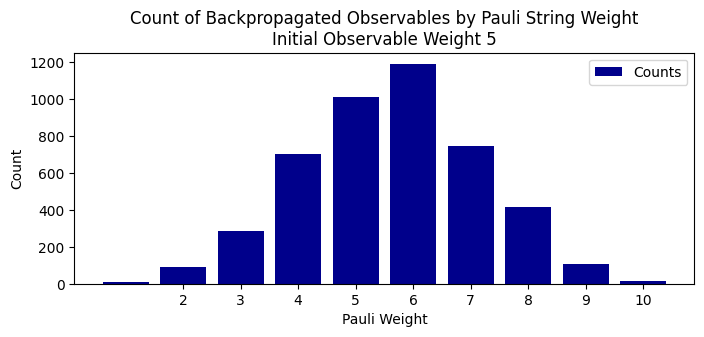

In [11]:
dat = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_QAOA'))
dat_df = pd.read_pickle(f'{dat}/coef-trunc_reps2_n10_k8_g073_b042_depth100.pkl')

p = {}
for d in dat_df['obs_shad_dict'][0]:

    if len([x for x in d['obs'] if x != 'I']) not in p:
        p[len([x for x in d['obs'] if x != 'I'])] = 1
    else:
        p[len([x for x in d['obs'] if x != 'I'])] += 1

avg = 0
count = 0
for k, v in p.items():
    avg += float(k) * float(v)
    count += float(v)
avg /= count
print(avg)

plt.figure(figsize=(8, 3))

plt.bar(p.keys(), p.values(), color='darkblue', label='Counts')

plt.xticks([2, 3, 4, 5, 6, 7, 8, 9, 10])

plt.xlabel('Pauli Weight')
plt.ylabel('Count')
plt.title('Count of Backpropagated Observables by Pauli String Weight\nInitial Observable Weight 5')
plt.legend()

In [34]:
shad_df

,shad_exp,exact_val,shad_error,abs_shad_error,num_meas,obs_group
0,-1.000000,0.039562,1.039562,1.039562,1,0
1,-1.000000,0.039562,1.039562,1.039562,1,0
2,-1.000000,0.039562,1.039562,1.039562,1,0
3,-1.000000,0.039562,1.039562,1.039562,1,0
4,1.000000,0.039562,-0.960438,0.960438,1,0
...,...,...,...,...,...,...
195,0.051995,0.039562,-0.012433,0.012433,400000,4
196,0.042322,0.039562,-0.002759,0.002759,400000,4
197,0.022975,0.039562,0.016588,0.016588,400000,4
198,-0.054414,0.039562,0.093976,0.093976,400000,4


['IIIIIIIIZZ', 'IIIZIIIIZX', 'IIZIZIIIZX', 'IZIIIZIIZX', 'IZZZZZIIZX', 'ZIIIIIIIZX', 'ZIZZZIIIZX', 'ZZIZIZIIZX', 'ZZZIZZIIZX', 'ZIZIZIIIZY', 'ZIIZIIIIZY', 'ZZZZZZIIZY', 'ZZIIIZIIZY', 'IIZZZIIIZY', 'IZZIZZIIZY', 'IZIZIZIIZY', 'IIZIZIIIXZ', 'IZIIIZIIXZ', 'ZIIIIIIIXZ', 'ZZZIZZIIXZ', 'IZZIZZIIYZ', 'ZZIIIZIIYZ', 'ZIZIZIIIYZ', 'IZIIIZIIXY', 'IZZZZZIIXY', 'IIIZIIIIXY', 'IIZIZIIIXY', 'ZZIZIZIIXY', 'ZIIIIIIIXY', 'ZIZZZIIIXY', 'IZIZIZIIXX', 'IZZIZZIIXX', 'IIIIIIIIXX', 'IIZZZIIIXX', 'ZZIIIZIIXX', 'ZZZZZZIIXX', 'ZIIZIIIIXX', 'ZIZIZIIIXX', 'IZZIZZIIYY', 'IZIZIZIIYY', 'IIZZZIIIYY', 'IIIIIIIIYY', 'ZZZZZZIIYY', 'ZZIIIZIIYY', 'ZIZIZIIIYY', 'ZIIZIIIIYY', 'IZZZZZIIYX', 'IZIIIZIIYX', 'IIZIZIIIYX', 'IIIZIIIIYX', 'ZZIZIZIIYX', 'ZIIIIIIIYX', 'ZIZZZIIIYX']


([<matplotlib.axis.XTick at 0x164e29cc0>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9')])

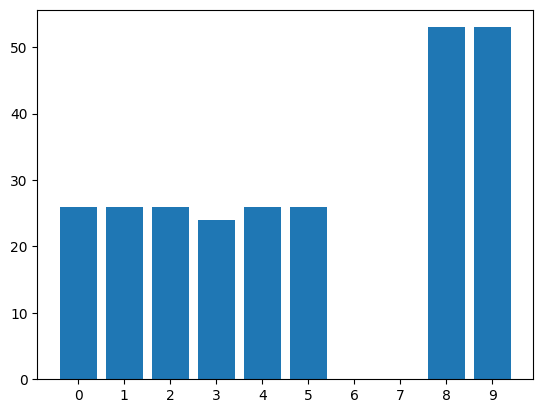

In [31]:
pauli_list = []

for p in test['bp_obs'][0].paulis:
    pauli_list.append(p.to_label())

print(pauli_list)

position_dict = {}
for p in pauli_list:
    for s in range(len(p)):
        if p[s] != 'I':
            if s in position_dict:
                position_dict[s] += 1
            else:
                position_dict[s] = 1

plt.bar(position_dict.keys(), position_dict.values())
plt.xticks(list(range(0,10)))

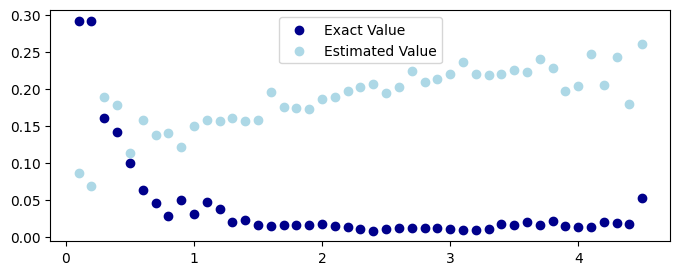

In [120]:
xyestimate = {}
xyexact = {}
xycount = {}

for d in test['obs_shad_dict'][0]:
    p = d['obs'] 
    pos = 0
    for s in range(len(p)):
        if p[s] != 'I':
            pos += s

    pos_avg = pos / 10
    if pos_avg not in xyexact:
        xyexact[pos_avg] = abs(d['exact'])
        xyestimate[pos_avg] = abs(d['estimate'])
        xycount[pos_avg] = 1
    else:
        xyexact[pos_avg] += abs(d['exact'])
        xyestimate[pos_avg] += abs(d['estimate'])
        xycount[pos_avg] += 1


# print(test['obs'][0])
# plt.bar(position_dict.keys(), position_dict.values())

for k in xyexact:
    xyexact[k] = xyexact[k] / xycount[k]
    xyestimate[k] = xyestimate[k] / xycount[k]

plt.figure(figsize=(8, 3))

plt.scatter(xyexact.keys(), xyexact.values(), color='darkblue', label='Exact Value')
plt.scatter(xyestimate.keys(), xyestimate.values(), color='lightblue', label='Estimated Value')

# plt.xticks(list(range(1,11)))

plt.legend()

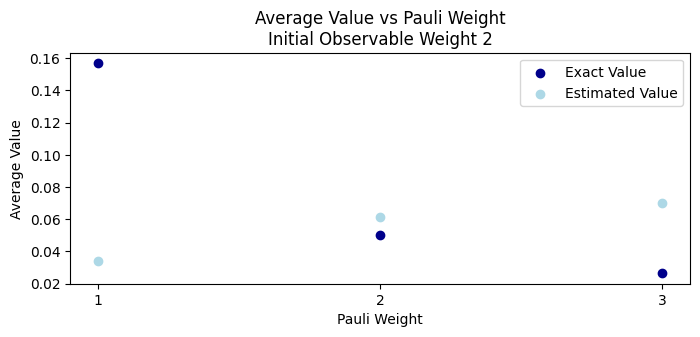

In [52]:
data_weight_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'QAOA_data'))
data_weight = pd.read_pickle(f'{data_weight_path}/bp-shad_reps2_n10_k3_g073_b042_depth70.pkl')
# data_weight = data_weight.tail(20)

xyestimate = {}
xyexact = {}
xycount = {}

for d in data_weight['obs_shad_dict'][0]:

    if len([x for x in d['obs'] if x != 'I']) not in xyexact:
        xyexact[len([x for x in d['obs'] if x != 'I'])] = abs(d['exact'])
        xyestimate[len([x for x in d['obs'] if x != 'I'])] = abs(d['estimate'])
        xycount[len([x for x in d['obs'] if x != 'I'])] = 1
    else:
        xyexact[len([x for x in d['obs'] if x != 'I'])] += abs(d['exact'])
        xyestimate[len([x for x in d['obs'] if x != 'I'])] += abs(d['estimate'])
        xycount[len([x for x in d['obs'] if x != 'I'])] += 1

for k in xyexact:
    xyexact[k] = xyexact[k] / xycount[k]
    xyestimate[k] = xyestimate[k] / xycount[k]

plt.figure(figsize=(8, 3))

plt.scatter(xyexact.keys(), xyexact.values(), color='darkblue', label='Exact Value')
plt.scatter(xyestimate.keys(), xyestimate.values(), color='lightblue', label='Estimated Value')

plt.xticks([1, 2, 3])

plt.xlabel('Pauli Weight')
plt.ylabel('Average Value')
plt.title('Average Value vs Pauli Weight\nInitial Observable Weight 2')
plt.legend()

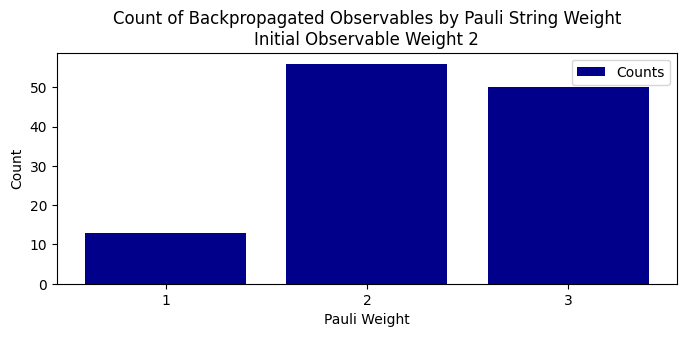

In [46]:
p = {}
for d in data_weight['obs_shad_dict'][0]:

    if len([x for x in d['obs'] if x != 'I']) not in p:
        p[len([x for x in d['obs'] if x != 'I'])] = 1
    else:
        p[len([x for x in d['obs'] if x != 'I'])] += 1

plt.figure(figsize=(8, 3))

plt.bar(p.keys(), p.values(), color='darkblue', label='Counts')

plt.xticks([1, 2, 3])

plt.xlabel('Pauli Weight')
plt.ylabel('Count')
plt.title('Count of Backpropagated Observables by Pauli String Weight\nInitial Observable Weight 2')
plt.legend()

/var/folders/zw/x8tsqxcx3lzdfvcr_bhldgg80000gn/T/ipykernel_42102/3499375961.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ev_est_dict[len([x for x in str(p) if x != 'I'])] = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['estimate'])
/var/folders/zw/x8tsqxcx3lzdfvcr_bhldgg80000gn/T/ipykernel_42102/3499375961.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ev_exact_dict[len([x for x in str(p) if x != 'I'])] = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['exact'])
/var/folders/zw/x8tsqxcx3lzdfvcr_bhldgg80000gn/T/ipykernel_42102/3499375961.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ev_est_dict[len([x for x in str(p) if x != 'I'])] += c.real * float(obs_sh

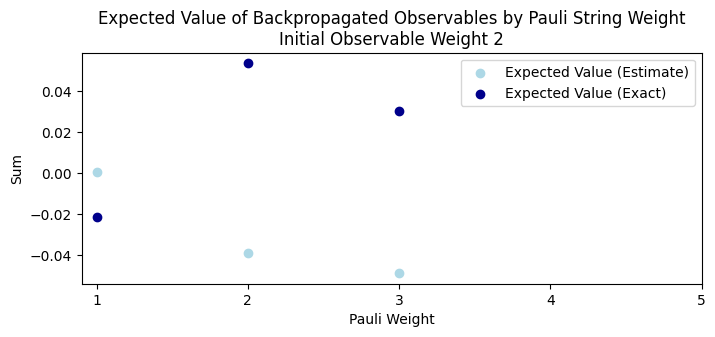

In [53]:
# estimated expected value by pauli weight
# exact expected value by pauli weight
# scatter plot
ev_est_dict = {}
ev_exact_dict = {}
obs_shad_df = pd.DataFrame(data_weight['obs_shad_dict'][0])
for p, c in zip(data_weight['bp_obs'][0].paulis, data_weight['bp_obs'][0].coeffs):
    if len([x for x in str(p) if x != 'I']) not in ev_est_dict:
        ev_est_dict[len([x for x in str(p) if x != 'I'])] = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['estimate'])
        ev_exact_dict[len([x for x in str(p) if x != 'I'])] = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['exact'])
    else:
        ev_est_dict[len([x for x in str(p) if x != 'I'])] += c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['estimate'])
        ev_exact_dict[len([x for x in str(p) if x != 'I'])] += c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['exact'])

# print(ev_est_dict)
plt.figure(figsize=(8, 3))

plt.scatter(ev_est_dict.keys(), ev_est_dict.values(), color='lightblue', label='Expected Value (Estimate)')
plt.scatter(ev_exact_dict.keys(), ev_exact_dict.values(), color='darkblue', label='Expected Value (Exact)')

plt.xticks([1, 2, 3, 4, 5])

plt.xlabel('Pauli Weight')
plt.ylabel('Sum')
plt.title('Expected Value of Backpropagated Observables by Pauli String Weight\nInitial Observable Weight 2')
plt.legend()

In Panel (a), the rightmost data point of the OBP-shadow protocol with three initial observables achieves the same accuracy as OBP while using 1.93× fewer measurements. In Panel (b), with nine initial observables, this improvement increases to 8.37×. Panel (c) shows an improvement of 11.28×, and Panel (d) 28.79×.}